# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

# Cargar datos
df = pd.read_csv('../data/taxi.csv', parse_dates=['datetime'], index_col='datetime')
df = df.sort_index()

# Remuestreo a intervalos de 1 hora (suma de pedidos dentro de cada hora)
df = df.resample('1h').sum()

print(f"Filas tras remuestreo: {df.shape[0]}")
print(f"Rango de fechas: {df.index.min()} → {df.index.max()}")
print(f"\nEstadísticas básicas:")
print(df.describe().round(2))

Filas tras remuestreo: 4416
Rango de fechas: 2018-03-01 00:00:00 → 2018-08-31 23:00:00

Estadísticas básicas:
       num_orders
count     4416.00
mean        84.42
std         45.02
min          0.00
25%         54.00
50%         78.00
75%        107.00
max        462.00


## Análisis

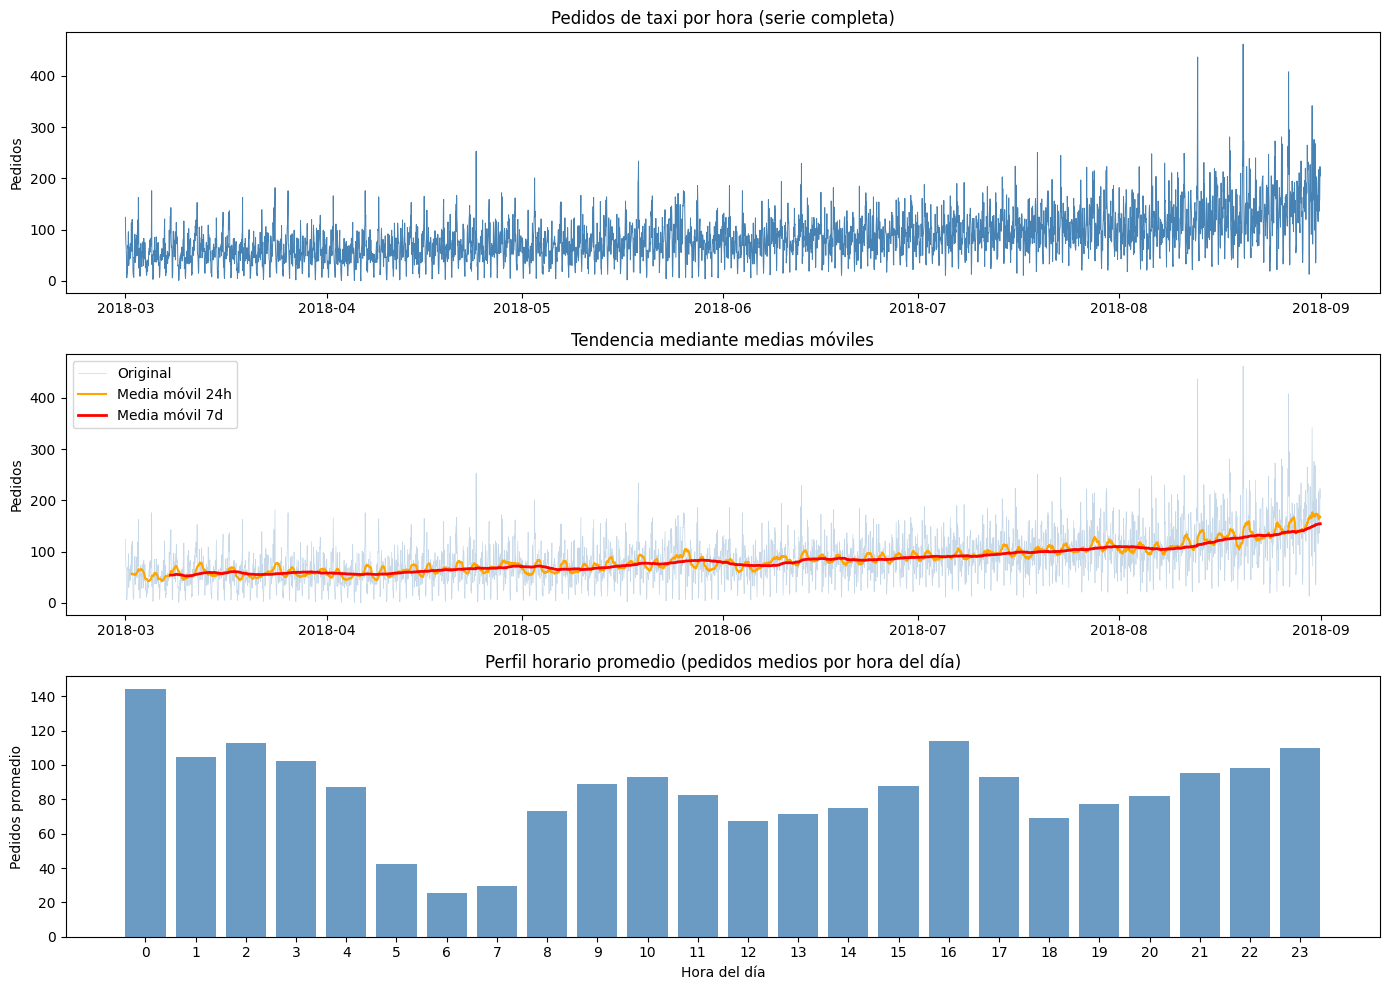

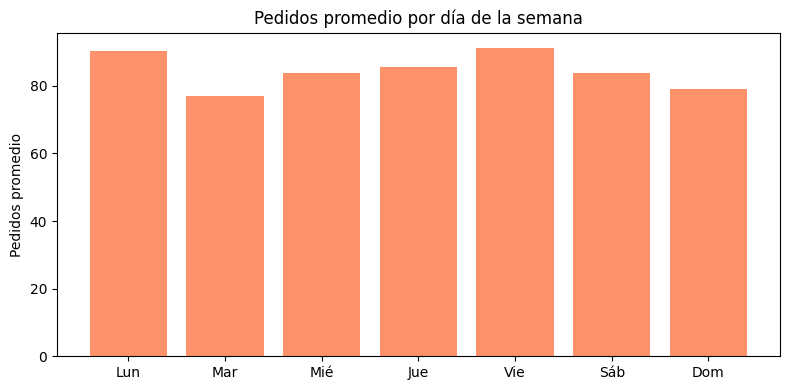

Observaciones:
  - Hora pico promedio: 0:00h (144.4 pedidos)
  - Hora valle promedio: 6:00h (25.2 pedidos)
  - Día con más pedidos: Vie (91.1)


In [2]:
# Serie temporal completa
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Serie completa
axes[0].plot(df.index, df['num_orders'], linewidth=0.7, color='steelblue')
axes[0].set_title('Pedidos de taxi por hora (serie completa)')
axes[0].set_ylabel('Pedidos')

# Media móvil de 24h y 168h (semanal)
df['roll_24'] = df['num_orders'].rolling(24).mean()
df['roll_168'] = df['num_orders'].rolling(168).mean()
axes[1].plot(df.index, df['num_orders'], alpha=0.3, linewidth=0.5, color='steelblue', label='Original')
axes[1].plot(df.index, df['roll_24'], linewidth=1.5, color='orange', label='Media móvil 24h')
axes[1].plot(df.index, df['roll_168'], linewidth=2, color='red', label='Media móvil 7d')
axes[1].set_title('Tendencia mediante medias móviles')
axes[1].set_ylabel('Pedidos')
axes[1].legend()

# Perfil horario promedio (por hora del día)
hourly_profile = df.groupby(df.index.hour)['num_orders'].mean()
axes[2].bar(hourly_profile.index, hourly_profile.values, color='steelblue', alpha=0.8)
axes[2].set_title('Perfil horario promedio (pedidos medios por hora del día)')
axes[2].set_xlabel('Hora del día')
axes[2].set_ylabel('Pedidos promedio')
axes[2].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

# Patrón semanal
weekly_profile = df.groupby(df.index.dayofweek)['num_orders'].mean()
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dias, weekly_profile.values, color='coral', alpha=0.85)
ax.set_title('Pedidos promedio por día de la semana')
ax.set_ylabel('Pedidos promedio')
plt.tight_layout()
plt.show()

print("Observaciones:")
print(f"  - Hora pico promedio: {hourly_profile.idxmax()}:00h ({hourly_profile.max():.1f} pedidos)")
print(f"  - Hora valle promedio: {hourly_profile.idxmin()}:00h ({hourly_profile.min():.1f} pedidos)")
print(f"  - Día con más pedidos: {dias[weekly_profile.idxmax()]} ({weekly_profile.max():.1f})")

# Eliminar columnas auxiliares de la serie
df = df.drop(columns=['roll_24', 'roll_168'])

## Formación

In [3]:
def make_features(data, max_lag, rolling_mean_size):
    """Genera características de rezago y media móvil para series de tiempo."""
    df_feat = data.copy()
    df_feat['hour'] = df_feat.index.hour
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['month'] = df_feat.index.month

    for lag in range(1, max_lag + 1):
        df_feat[f'lag_{lag}'] = df_feat['num_orders'].shift(lag)

    df_feat['rolling_mean'] = df_feat['num_orders'].shift(1).rolling(rolling_mean_size).mean()
    return df_feat.dropna()


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


# Construcción de características: 24 rezagos (24h atrás) + media móvil 24h
df_feat = make_features(df, max_lag=24, rolling_mean_size=24)

# División temporal: último 10% como prueba
test_size = int(len(df_feat) * 0.1)
df_train = df_feat.iloc[:-test_size]
df_test  = df_feat.iloc[-test_size:]

TARGET = 'num_orders'
feature_cols = [c for c in df_feat.columns if c != TARGET]

X_train, y_train = df_train[feature_cols], df_train[TARGET]
X_test,  y_test  = df_test[feature_cols],  df_test[TARGET]

print(f"Entrenamiento: {len(df_train)} filas  ({df_train.index.min().date()} → {df_train.index.max().date()})")
print(f"Prueba:        {len(df_test)} filas  ({df_test.index.min().date()} → {df_test.index.max().date()})")
print(f"Características: {len(feature_cols)}")

# ── Modelos ──────────────────────────────────────────────────────────────────
results = []

# 1. Regresión lineal (línea base)
t0 = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
t_train = time.time() - t0

t0 = time.time()
y_pred_lr = lr.predict(X_test)
t_pred = time.time() - t0

r = rmse(y_test, y_pred_lr)
print(f"\nRegresión Lineal       — RECM: {r:.2f} | Entreno: {t_train:.2f}s | Pred: {t_pred:.4f}s")
results.append({'Modelo': 'Regresión Lineal', 'RECM': r, 'T_entreno (s)': t_train, 'T_pred (s)': t_pred})

# 2. Bosque Aleatorio — config 1
t0 = time.time()
rf1 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=12345, n_jobs=-1)
rf1.fit(X_train, y_train)
t_train = time.time() - t0

t0 = time.time()
y_pred_rf1 = rf1.predict(X_test)
t_pred = time.time() - t0

r = rmse(y_test, y_pred_rf1)
print(f"Bosque Aleatorio cfg1  — RECM: {r:.2f} | Entreno: {t_train:.2f}s | Pred: {t_pred:.4f}s")
results.append({'Modelo': 'Bosque Aleatorio (cfg1)', 'RECM': r, 'T_entreno (s)': t_train, 'T_pred (s)': t_pred})
del rf1

# 3. Bosque Aleatorio — config 2
t0 = time.time()
rf2 = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=2, random_state=12345, n_jobs=-1)
rf2.fit(X_train, y_train)
t_train = time.time() - t0

t0 = time.time()
y_pred_rf2 = rf2.predict(X_test)
t_pred = time.time() - t0

r = rmse(y_test, y_pred_rf2)
print(f"Bosque Aleatorio cfg2  — RECM: {r:.2f} | Entreno: {t_train:.2f}s | Pred: {t_pred:.4f}s")
results.append({'Modelo': 'Bosque Aleatorio (cfg2)', 'RECM': r, 'T_entreno (s)': t_train, 'T_pred (s)': t_pred})
del rf2

# 4. LightGBM — config 1
t0 = time.time()
lgbm1 = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=8,
                            num_leaves=63, random_state=12345, n_jobs=-1, verbosity=-1)
lgbm1.fit(X_train, y_train)
t_train = time.time() - t0

t0 = time.time()
y_pred_lgbm1 = lgbm1.predict(X_test)
t_pred = time.time() - t0

r = rmse(y_test, y_pred_lgbm1)
print(f"LightGBM cfg1          — RECM: {r:.2f} | Entreno: {t_train:.2f}s | Pred: {t_pred:.4f}s")
results.append({'Modelo': 'LightGBM (cfg1)', 'RECM': r, 'T_entreno (s)': t_train, 'T_pred (s)': t_pred})
del lgbm1

# 5. LightGBM — config 2
t0 = time.time()
lgbm2 = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.1, max_depth=6,
                            num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                            random_state=12345, n_jobs=-1, verbosity=-1)
lgbm2.fit(X_train, y_train)
t_train = time.time() - t0

t0 = time.time()
y_pred_lgbm2 = lgbm2.predict(X_test)
t_pred = time.time() - t0

r = rmse(y_test, y_pred_lgbm2)
print(f"LightGBM cfg2          — RECM: {r:.2f} | Entreno: {t_train:.2f}s | Pred: {t_pred:.4f}s")
results.append({'Modelo': 'LightGBM (cfg2)', 'RECM': r, 'T_entreno (s)': t_train, 'T_pred (s)': t_pred})

Entrenamiento: 3953 filas  (2018-03-02 → 2018-08-13)
Prueba:        439 filas  (2018-08-13 → 2018-08-31)
Características: 28

Regresión Lineal       — RECM: 45.74 | Entreno: 0.00s | Pred: 0.0005s
Bosque Aleatorio cfg1  — RECM: 44.69 | Entreno: 0.14s | Pred: 0.0141s
Bosque Aleatorio cfg2  — RECM: 42.87 | Entreno: 0.27s | Pred: 0.0266s
LightGBM cfg1          — RECM: 41.26 | Entreno: 49.85s | Pred: 0.0016s
LightGBM cfg2          — RECM: 40.68 | Entreno: 0.54s | Pred: 0.0031s


## Prueba

COMPARACIÓN DE MODELOS EN CONJUNTO DE PRUEBA


,Modelo,RECM,T_entreno (s),T_pred (s)
0,LightGBM (cfg2),40.68,0.541,0.0031
1,LightGBM (cfg1),41.26,49.847,0.0016
2,Bosque Aleatorio (cfg2),42.87,0.271,0.0266
3,Bosque Aleatorio (cfg1),44.69,0.140,0.0141
4,Regresión Lineal,45.74,0.003,0.0005



Mejor modelo: LightGBM (cfg2) — RECM: 40.68
Modelos que cumplen RECM ≤ 48: 5 de 5
✓ Cumple el requisito


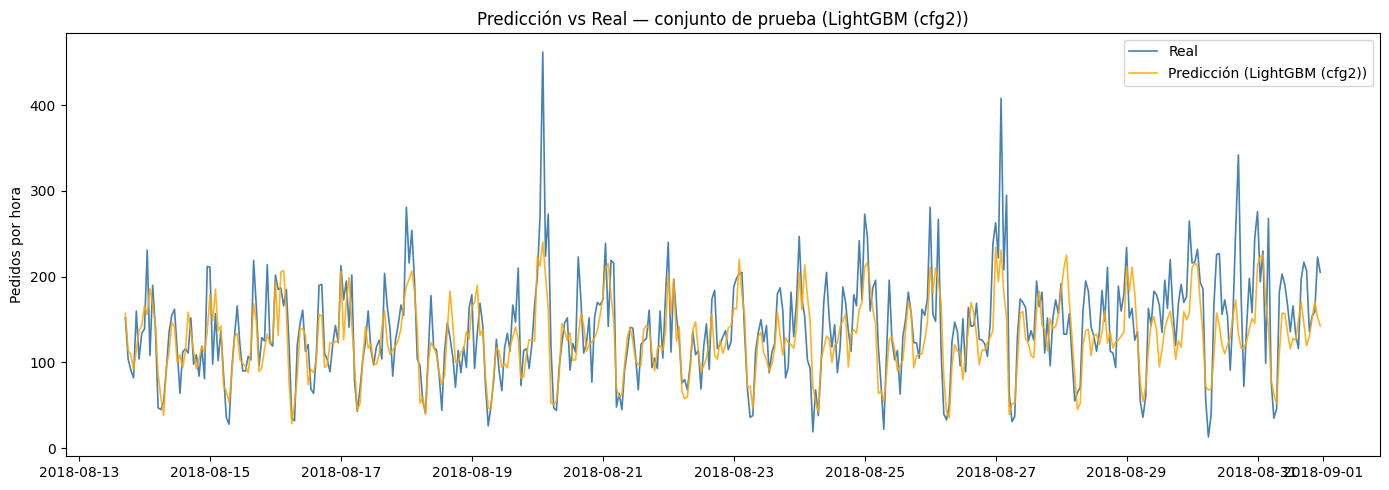

In [5]:
from IPython.display import display

# Tabla comparativa
df_results = pd.DataFrame(results).sort_values('RECM').reset_index(drop=True)
df_results['RECM'] = df_results['RECM'].round(2)
df_results['T_entreno (s)'] = df_results['T_entreno (s)'].round(3)
df_results['T_pred (s)'] = df_results['T_pred (s)'].round(4)

print("=" * 65)
print("COMPARACIÓN DE MODELOS EN CONJUNTO DE PRUEBA")
print("=" * 65)
display(df_results)

umbral = 48
mejor = df_results.iloc[0]
modelos_ok = df_results[df_results['RECM'] <= umbral]
print(f"\nMejor modelo: {mejor['Modelo']} — RECM: {mejor['RECM']:.2f}")
print(f"Modelos que cumplen RECM ≤ {umbral}: {len(modelos_ok)} de {len(df_results)}")
print(f"{'✓ Cumple el requisito' if mejor['RECM'] <= umbral else '✗ No cumple el requisito'}")

# Gráfico: predicción vs real (mejor modelo)
mejor_nombre = mejor['Modelo']
pred_map = {
    'Regresión Lineal':        y_pred_lr,
    'LightGBM (cfg1)':         y_pred_lgbm1,
    'LightGBM (cfg2)':         y_pred_lgbm2,
}
best_pred = pred_map.get(mejor_nombre, y_pred_lgbm2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_test.index, y_test.values, label='Real', linewidth=1.2, color='steelblue')
ax.plot(df_test.index, best_pred, label=f'Predicción ({mejor_nombre})',
        linewidth=1.2, color='orange', alpha=0.85)
ax.set_title(f'Predicción vs Real — conjunto de prueba ({mejor_nombre})')
ax.set_ylabel('Pedidos por hora')
ax.legend()
plt.tight_layout()
plt.show()



### Conlusiones

Se entrenaron 5 modelos sobre características de series de tiempo: rezagos de 1 a 24 horas, media móvil de 24h y variables de calendario (hora, día de la semana, mes). La división entrenamiento/prueba respeta el orden temporal (último 10% = prueba), evitando fuga de datos futura.

El análisis de la serie reveló:
  - Tendencia creciente pronunciada: el promedio de pedidos pasó de ~58/h en marzo a ~128/h en agosto (más del doble en 6 meses).
  - Ciclo diario claro: pico a las 0:00h (~144 pedidos) y valle a las 6:00h (~25 pedidos).
  - Ciclo semanal leve: el viernes concentra el mayor número de pedidos (91.1 de media), mientras que el martes es el día más bajo (77.0).

Todos los modelos superaron el umbral requerido (RECM ≤ 48). LightGBM obtuvo los mejores resultados en ambas configuraciones. La Regresión Lineal, aunque es el peor modelo del conjunto (RECM = 45.74), también cumple el requisito gracias al poder predictivo de los rezagos horarios.

El mejor modelo es LightGBM (cfg2) con RECM = 40.68 en el conjunto de prueba, muy por debajo del límite de 48.

# Lista de revisión

- [x]  Jupyter Notebook está abierto.
- [x]  El código no tiene errores
- [x]  Las celdas con el código han sido colocadas en el orden de ejecución.
- [x]  Los datos han sido descargados y preparados.
- [x]  Se ha realizado el paso 2: los datos han sido analizados
- [x]  Se entrenó el modelo y se seleccionaron los hiperparámetros
- [x]  Se han evaluado los modelos. Se expuso una conclusión
- [x] La *RECM* para el conjunto de prueba no es más de 48